[![In Colab öffnen](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Y-Robin/DeepLearningKurs/blob/main/notebooks/Day_6_8/01_tag_6_8_intro_pytorch_setup_gpu.ipynb)

# Tag 6-8 - 01 PyTorch-Intro: Modell, Loss, Optimizer, Training

Dieses Beispiel gibt den PyTorch-Überblick, den man vor CNNs braucht: Tensoren, Layer, Klassen, Forward Pass, Loss, Backward Pass, Train Step, L2-Regularisierung, Lernrate, eigene Funktionen und Speichern/Laden.


## Installation und Device

`requirements.txt` enthält bewusst kein PyTorch. Nach der Basisinstallation wird genau eine PyTorch-Variante installiert:

```bash
# NVIDIA-GPU unter Windows/Linux
python -m pip install -r requirements-torch-cu126.txt

# CPU-only unter Windows/Linux
python -m pip install -r requirements-torch-cpu.txt
```

Die CUDA-12.6-Wheels enthalten die CUDA-Laufzeit; erforderlich ist ein aktueller kompatibler NVIDIA-Treiber. `environment.yml` kann nicht zuverlässig automatisch prüfen, ob eine GPU vorhanden ist und dann abhängig davon einen anderen pip-index wählen. Deshalb ist der GPU-Schritt separat.

PyTorch arbeitet explizit mit einem `device`: Modell und Daten müssen auf dasselbe Gerät (`cpu` oder `cuda`) verschoben werden. Genau das wird in den Trainingsfunktionen unten gemacht.

In [1]:
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = False
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, Dataset, random_split

torch.manual_seed(RANDOM_STATE)


def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


device = pick_device()
print("PyTorch:", torch.__version__)
print("CUDA verfügbar:", torch.cuda.is_available())
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.7.1+cu126
CUDA verfügbar: True
Device: cuda
GPU: NVIDIA GeForce RTX 3080


## Trainings-Hilfsfunktionen

Die nächsten Funktionen bilden den Standard-Trainingsablauf in PyTorch ab:

- `model.train()` schaltet das Modell in den Trainingsmodus. Das ist relevant für Layer wie `Dropout` und `BatchNorm`.
- `optimizer.zero_grad()` löscht alte Gradienten.
- `logits = model(xb)` ruft intern `forward` auf.
- `loss.backward()` berechnet Gradienten per Backpropagation.
- `optimizer.step()` aktualisiert die Parameter.
- `model.eval()` schaltet das Modell für die Auswertung um.
- `torch.no_grad()` spart Speicher, weil in der Evaluation keine Gradienten gebraucht werden.

In [2]:
def accuracy_from_logits(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()


def train_step(model, xb, yb, loss_fn, optimizer):
    # Trainingsmodus aktivieren: wichtig für Dropout/BatchNorm.
    model.train()
    # Daten auf dasselbe Gerät wie das Modell verschieben.
    xb, yb = xb.to(device), yb.to(device)
    # Alte Gradienten löschen, sonst würden sie akkumulieren.
    optimizer.zero_grad()
    # Forward Pass: Modell erzeugt Logits.
    logits = model(xb)
    # Loss berechnen.
    loss = loss_fn(logits, yb)
    # Backward Pass: Gradienten berechnen.
    loss.backward()
    # Optimizer-Schritt: Gewichte aktualisieren.
    optimizer.step()
    return loss.item(), accuracy_from_logits(logits.detach(), yb)


def evaluate(model, loader, loss_fn=None):
    # Evaluationsmodus: Dropout aus, BatchNorm stabil.
    model.eval()
    total_loss = 0.0
    correct = 0
    seen = 0
    # Keine Gradienten in der Evaluation nötig.
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            if loss_fn is not None:
                total_loss += loss_fn(logits, yb).item() * len(xb)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            seen += len(xb)
    avg_loss = total_loss / seen if loss_fn is not None else np.nan
    return avg_loss, correct / seen


def train_epochs(model, train_loader, valid_loader, loss_fn, optimizer, epochs=5):
    history = []
    for epoch in range(epochs):
        losses = []
        accs = []
        for xb, yb in train_loader:
            loss, acc = train_step(model, xb, yb, loss_fn, optimizer)
            losses.append(loss)
            accs.append(acc)
        valid_loss, valid_acc = evaluate(model, valid_loader, loss_fn)
        row = {
            "epoch": epoch + 1,
            "train_loss": float(np.mean(losses)),
            "train_acc": float(np.mean(accs)),
            "valid_loss": float(valid_loss),
            "valid_acc": float(valid_acc),
        }
        history.append(row)
        print(
            f"Epoch {row['epoch']:02d}: "
            f"train_loss={row['train_loss']:.3f}, train_acc={row['train_acc']:.3f}, "
            f"valid_loss={row['valid_loss']:.3f}, valid_acc={row['valid_acc']:.3f}"
        )
    return history


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## Wichtige Layer in PyTorch

`torch.nn` enthält die Bausteine:

- `nn.Linear(in_features, out_features)`: Dense Layer für tabellarische Daten oder den Klassifikationskopf.
- `nn.ReLU()`, `nn.Sigmoid()`, `nn.Tanh()`: Aktivierungsfunktionen.
- `nn.Dropout(p)`: deaktiviert im Training zufällig Aktivierungen, Regularisierung gegen Overfitting.
- `nn.BatchNorm1d(num_features)`: normalisiert Aktivierungen in MLPs.
- `nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)`: Convolution für Bilder.
- `nn.MaxPool2d(kernel_size, stride=None, padding=0)`: reduziert räumliche Auflösung.

Alle Module bekommen Tensoren als Input und geben Tensoren zurück. Für Klassifikation mit `nn.CrossEntropyLoss` gibt das Modell rohe Logits der Form `(batch, num_classes)` aus; die Labels haben die Form `(batch,)` und dtype `torch.long`.


## Datensatz für ein MLP

Der Datensatz wird hier absichtlich nur mit NumPy erzeugt. Dadurch hängt die erste PyTorch-Einführung nicht von weiteren nativen ML-Paketen ab. Wenn ein Jupyter-Kernel direkt nach der GPU-Ausgabe stirbt, liegt das oft an nativen Paket-/DLL-Konflikten bei späteren Imports. Diese Zelle vermeidet solche zusätzlichen Imports.

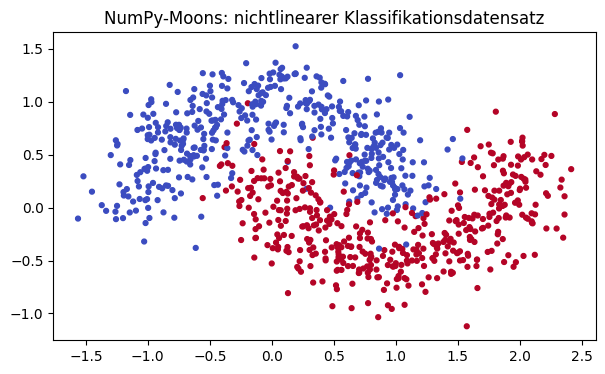

In [3]:
def make_moons_numpy(n_samples=900, noise=0.22, seed=RANDOM_STATE):
    """Kleine NumPy-Version von make_moons ohne zusätzliche ML-Bibliothek.

    Output:
    - X: Feature-Matrix mit Shape (n_samples, 2)
    - y: Klassenlabels mit Shape (n_samples,)
    """
    rng = np.random.default_rng(seed)
    n_outer = n_samples // 2
    n_inner = n_samples - n_outer

    outer_angles = rng.uniform(0, np.pi, n_outer)
    inner_angles = rng.uniform(0, np.pi, n_inner)

    outer = np.c_[np.cos(outer_angles), np.sin(outer_angles)]
    inner = np.c_[1 - np.cos(inner_angles), 0.5 - np.sin(inner_angles)]

    X = np.vstack([outer, inner]).astype(np.float32)
    y = np.array([0] * n_outer + [1] * n_inner, dtype=np.int64)
    X += rng.normal(0, noise, size=X.shape).astype(np.float32)

    order = rng.permutation(n_samples)
    return X[order], y[order]


def stratified_split_numpy(X, y, valid_fraction=0.25, seed=RANDOM_STATE):
    """Einfacher stratifizierter Split nur mit NumPy."""
    rng = np.random.default_rng(seed)
    train_indices = []
    valid_indices = []
    for cls in np.unique(y):
        cls_indices = np.where(y == cls)[0]
        rng.shuffle(cls_indices)
        n_valid = int(round(len(cls_indices) * valid_fraction))
        valid_indices.extend(cls_indices[:n_valid])
        train_indices.extend(cls_indices[n_valid:])
    rng.shuffle(train_indices)
    rng.shuffle(valid_indices)
    return X[train_indices], X[valid_indices], y[train_indices], y[valid_indices]


X, y = make_moons_numpy(n_samples=900, noise=0.22)
X_train, X_valid, y_train, y_valid = stratified_split_numpy(X, y, valid_fraction=0.25)

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=64, shuffle=True)
valid_loader = DataLoader(TensorDataset(torch.tensor(X_valid), torch.tensor(y_valid)), batch_size=256)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=12)
ax.set_title("NumPy-Moons: nichtlinearer Klassifikationsdatensatz")
plt.show()


## Modell als Klasse

Bei eigenen Modellen erbt man von `nn.Module`. In `__init__` werden Layer definiert. In `forward` steht, wie ein Batch durch das Modell läuft.


In [ ]:
class SquarePlus(nn.Module):
    """Eigene Aktivierungsfunktion als PyTorch-Modul.

    Input: Tensor beliebiger Form.
    Output: Tensor gleicher Form.
    Diese Klasse muss beim Laden des Modells wieder definiert sein,
    weil MoonMLP sie in seiner Architektur verwendet.
    """
    def forward(self, x):
        return 0.5 * (x + torch.sqrt(x * x + 4))


class MoonMLP(nn.Module):
    def __init__(self, hidden_units=32, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_units),
            SquarePlus(),
            nn.Dropout(dropout),
            nn.Linear(hidden_units, hidden_units),
            SquarePlus(),
            # Eine dritte versteckte Schicht erlaubt komplexere, gekrümmte Entscheidungsgrenzen.
            nn.Linear(hidden_units, hidden_units),
            SquarePlus(),
            nn.Linear(hidden_units, 2),
        )

    def forward(self, x):
        # x: (batch, 2)
        # return: rohe Logits, Shape (batch, 2)
        return self.net(x)

model = MoonMLP(hidden_units=32, dropout=0.1).to(device)
print(model)
print("Parameter:", count_params(model))


MoonMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=32, bias=True)
    (6): ReLU()
    (7): Linear(in_features=32, out_features=2, bias=True)
  )
)
Parameter: 2274


## Ein einzelner Forward-/Backward-Schritt

Der Trainingsschritt besteht immer aus derselben Reihenfolge:

1. Batch auf dasselbe Gerät wie das Modell legen.
2. `optimizer.zero_grad()`: alte Gradienten löschen.
3. `logits = model(xb)`: Forward Pass.
4. `loss = loss_fn(logits, yb)`: Fehler berechnen.
5. `loss.backward()`: Backpropagation, Gradienten berechnen.
6. `optimizer.step()`: Gewichte aktualisieren.


In [5]:
demo_model = MoonMLP(hidden_units=16, dropout=0.0).to(device)
demo_loss_fn = nn.CrossEntropyLoss()
demo_optimizer = torch.optim.SGD(demo_model.parameters(), lr=0.1, weight_decay=1e-4)

xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)

demo_optimizer.zero_grad()
logits = demo_model(xb)
loss = demo_loss_fn(logits, yb)
loss.backward()
demo_optimizer.step()

print("Input:", xb.shape)
print("Logits:", logits.shape)
print("Loss:", float(loss.detach().cpu()))
first_weight = next(demo_model.parameters())
print("Gradient-Shape erstes Gewicht:", first_weight.grad.shape)


Input: torch.Size([64, 2])
Logits: torch.Size([64, 2])
Loss: 0.6814695596694946
Gradient-Shape erstes Gewicht: torch.Size([16, 2])


## Loss, Optimizer, Lernrate, L2 und Trainingsmodus

- `loss_fn = nn.CrossEntropyLoss()`: misst den Klassifikationsfehler für Logits und Klassenlabels.
- `optimizer = torch.optim.Adam(...)`: aktualisiert die Gewichte.
- `lr`: Lernrate, also Schrittgröße der Optimierung.
- `weight_decay`: L2-Regularisierung. Große Gewichte werden bestraft, was Overfitting reduzieren kann.
- `model.train()`: Trainingsmodus. Dropout ist aktiv, BatchNorm würde Batch-Statistiken aktualisieren.
- `model.eval()`: Auswertungsmodus. Dropout ist aus, BatchNorm nutzt gespeicherte Statistiken.
- `torch.no_grad()`: schaltet Gradientenberechnung aus. Das spart Speicher und verhindert versehentliche Backpropagation bei Evaluation oder Vorhersage.


In [6]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
history = train_epochs(model, train_loader, valid_loader, loss_fn, optimizer, epochs=25)


Epoch 01: train_loss=0.516, train_acc=0.801, valid_loss=0.298, valid_acc=0.871
Epoch 02: train_loss=0.286, train_acc=0.874, valid_loss=0.246, valid_acc=0.911
Epoch 03: train_loss=0.232, train_acc=0.900, valid_loss=0.211, valid_acc=0.938
Epoch 04: train_loss=0.188, train_acc=0.924, valid_loss=0.186, valid_acc=0.938
Epoch 05: train_loss=0.165, train_acc=0.936, valid_loss=0.188, valid_acc=0.924
Epoch 06: train_loss=0.154, train_acc=0.935, valid_loss=0.173, valid_acc=0.938
Epoch 07: train_loss=0.123, train_acc=0.953, valid_loss=0.145, valid_acc=0.938
Epoch 08: train_loss=0.148, train_acc=0.943, valid_loss=0.175, valid_acc=0.938
Epoch 09: train_loss=0.127, train_acc=0.954, valid_loss=0.148, valid_acc=0.938
Epoch 10: train_loss=0.121, train_acc=0.949, valid_loss=0.137, valid_acc=0.946
Epoch 11: train_loss=0.111, train_acc=0.958, valid_loss=0.178, valid_acc=0.933
Epoch 12: train_loss=0.121, train_acc=0.959, valid_loss=0.157, valid_acc=0.942
Epoch 13: train_loss=0.115, train_acc=0.962, valid_l

## Eigene Metrik und Entscheidungsfläche


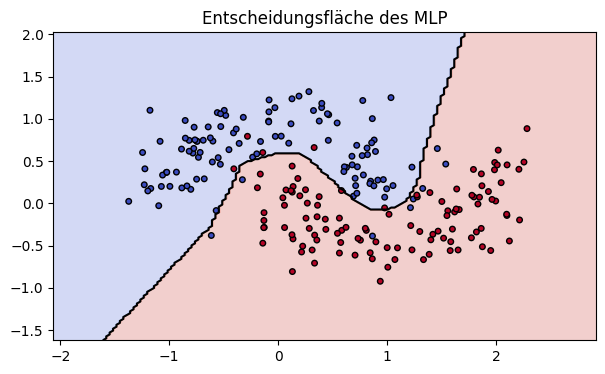

In [7]:
def predict_classes(model, X_np):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X_np, dtype=torch.float32).to(device))
        return logits.argmax(dim=1).cpu().numpy()

xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 160),
                     np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 160))
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
zz = predict_classes(model, grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 4))
ax.contourf(xx, yy, zz, alpha=0.25, cmap="coolwarm")
ax.contour(xx, yy, zz, levels=[0.5], colors="black", linewidths=1.5)
ax.scatter(X_valid[:, 0], X_valid[:, 1], c=y_valid, cmap="coolwarm", s=16, edgecolor="k")
ax.set_title("Entscheidungsfläche des MLP")
plt.show()


## Speichern und Laden


In [8]:
from pathlib import Path

out_dir = Path("saved_models")
out_dir.mkdir(exist_ok=True)
path = out_dir / "moon_mlp.pt"

torch.save({
    "model_state": model.state_dict(),
    "config": {"hidden_units": 32, "dropout": 0.1},
}, path)

checkpoint = torch.load(path, map_location=device)
loaded = MoonMLP(**checkpoint["config"]).to(device)
loaded.load_state_dict(checkpoint["model_state"])

valid_loss, valid_acc = evaluate(loaded, valid_loader, loss_fn)
print("Geladenes Modell valid_acc:", round(valid_acc, 3))


Geladenes Modell valid_acc: 0.942
